# 🌳 Análisis de Cobertura de la Tierra (IDEAM 2022) - Exploración Completa

**Objetivo**: Cargar y visualizar el Shapefile completo de Coberturas de la Tierra que se descargó. Dado que el recorte del Valle del Cauca resultó vacío, sospechamos que este archivo no es de cobertura nacional, sino que corresponde a otra región geográfica de Colombia (probablemente Sur-Oriente / Amazonía).

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (18, 14)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

BASE_DIR = Path('.').resolve().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
REPORTS_DIR = BASE_DIR / 'data' / 'reports'

COBERTURA_FILE = PROCESSED_DIR / 'Coberturas_de_la_Tierra_2022_SI_Escala_1_25000' / 'Coberturas_de_la_Tierra_25K_2022_SI.shp'

print('Librerías listas.')

Librerías listas.


## 1. Carga Completa del Shapefile
Vamos a cargar el archivo en su totalidad para descubrir qué área de Colombia abarca realmente.

In [2]:
print("Cargando Shapefile completo (esto tomará entre 30 y 60 segundos debido a los 330MB)...")
gdf_cob = gpd.read_file(COBERTURA_FILE)

print(f"\n¡Carga exitosa! Total de polígonos: {len(gdf_cob):,}")
print(f"Sistema de Coordenadas (CRS): {gdf_cob.crs}")
print(f"Límites geográficos (Bounding Box): {gdf_cob.total_bounds}")

display(gdf_cob[['cobertura', 'cob_agrup', 'area_ha']].sample(5))

Cargando Shapefile completo (esto tomará entre 30 y 60 segundos debido a los 330MB)...

¡Carga exitosa! Total de polígonos: 72,540
Sistema de Coordenadas (CRS): EPSG:4170
Límites geográficos (Bounding Box): [-76.49361211  -0.13601774 -67.70618035   4.1676077 ]


,cobertura,cob_agrup,area_ha
51656,Pasto limpio denso inundable,Pastizales,13.269982
6222,Bosque denso alto de tierra firme,Bosques,10.140849
53937,Pasto limpio denso de tierra firme,Pastizales,2.433056
1399,Pasto limpio denso de tierra firme,Pastizales,12.143924
2450,Pastos abiertos arbolados inundables,Pastizales,8.155912


## 2. Mapa Exploratorio (Realidad)
Dibujaremos todos los polígonos coloreados por su agrupación principal para ver la forma del territorio que cubre este dataset.

Renderizando mapa... (puede tomar un momento)


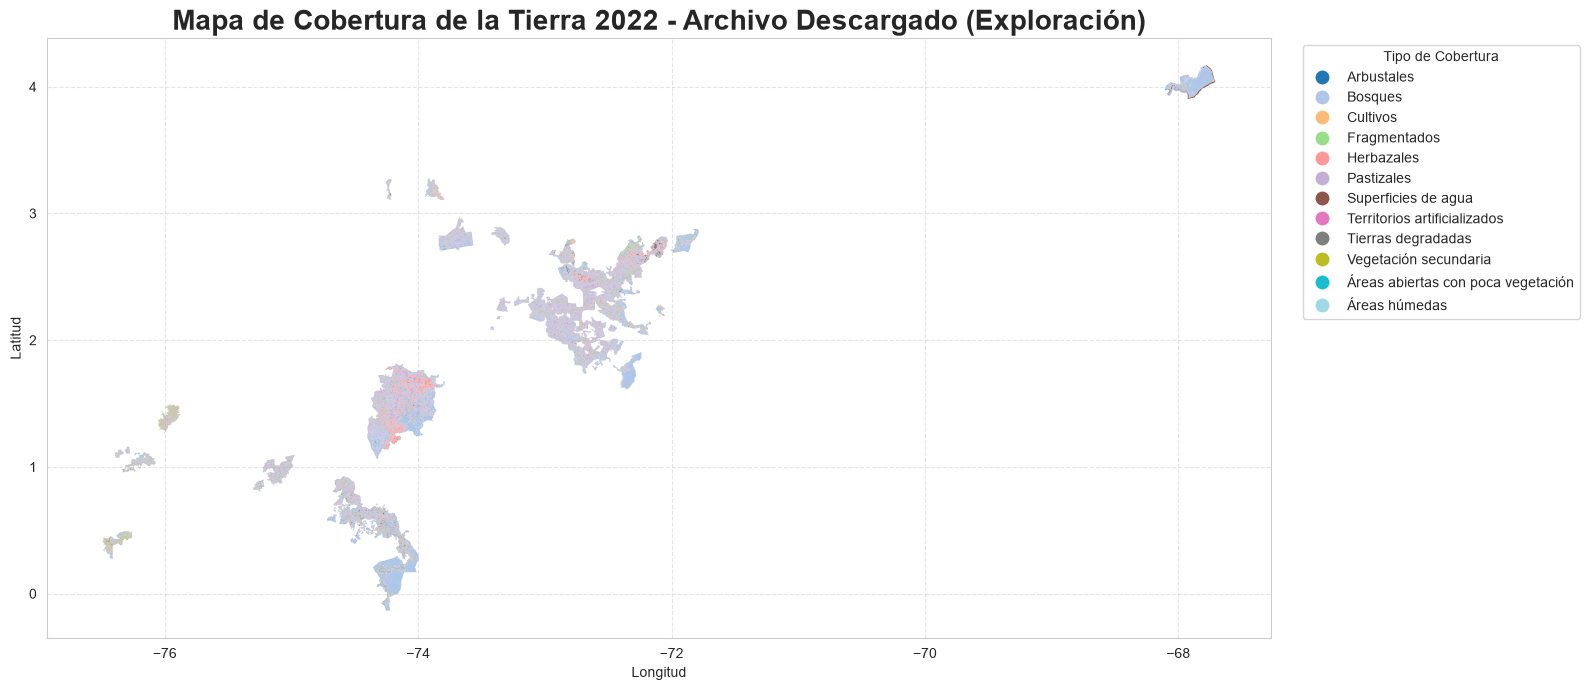

In [3]:
if not gdf_cob.empty:
    fig, ax = plt.subplots(figsize=(16, 16))

    # Definir la columna a colorear
    columna_color = 'cob_agrup' if 'cob_agrup' in gdf_cob.columns else 'cobertura'
    
    print("Renderizando mapa... (puede tomar un momento)")
    gdf_cob.plot(column=columna_color,
                 ax=ax,
                 legend=True,
                 cmap='tab20',
                 edgecolor='none',
                 legend_kwds={'bbox_to_anchor': (1.02, 1), 'loc': 'upper left', 'title': 'Tipo de Cobertura'})

    ax.set_title('Mapa de Cobertura de la Tierra 2022 - Archivo Descargado (Exploración)', fontsize=20, fontweight='bold')
    
    # Agregar cuadrícula para ver latitudes y longitudes
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fig_mapa_cobertura_exploracion.png', dpi=150)
    plt.show()
else:
    print("No hay datos para mapear.")

## 3. Estadísticas de este Territorio
Veamos de qué está compuesto principalmente este misterioso territorio.

In [4]:
if not gdf_cob.empty:
    print("Distribución Top 15 de Coberturas en la región descargada (Hectáreas):\n")
    
    # Como no sabemos la región exacta, sumaremos directamente la columna area_ha que viene en el shapefile
    if 'area_ha' in gdf_cob.columns:
        resumen = gdf_cob.groupby(columna_color)['area_ha'].sum().sort_values(ascending=False).head(15)
    else:
        # Si no hay, calculamos una aproximación
        gdf_cob['area_aprox'] = gdf_cob.to_crs("EPSG:3116").geometry.area / 10000
        resumen = gdf_cob.groupby(columna_color)['area_aprox'].sum().sort_values(ascending=False).head(15)
        
    display(resumen.to_frame().style.format('{:,.1f}').bar(color='#66c2a5'))
else:
    print("No hay datos para analizar.")

Distribución Top 15 de Coberturas en la región descargada (Hectáreas):



,area_ha
cob_agrup,
Bosques,"741,999.7"
Pastizales,"582,272.6"
Vegetación secundaria,"91,897.5"
Herbazales,"64,042.4"
Tierras degradadas,"22,333.2"
Superficies de agua,"18,123.0"
Fragmentados,"5,768.3"
Cultivos,"5,098.0"
Arbustales,"2,735.0"


### 🔎 Diagnóstico:
Si al ver el mapa notas que la silueta no corresponde al mapa completo de Colombia ni al Valle del Cauca (que está al oeste del país, longitud -76 a -77), significa que este archivo de datos abiertos corresponde probablemente a la Amazonía, Caquetá o Putumayo (Longitudes -76 a -67, Latitudes 0 a 4).

Para el modelo predictivo, necesitaríamos buscar en datos.gov.co la versión **Nacional** de Corine Land Cover o específicamente la del Valle del Cauca.